# Solvent Accessibility Analysis (SASA & RSA) for PDB Structures

This notebook calculates Solvent Accessible Surface Area (SASA) and Relative Solvent Accessibility (RSA) for all sites in PDB files, both with and without antigen present.

Adapted from Dave's code: dnsm-experiments-1/dnsmex/dms_viz.py

In [144]:
import os
import random
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

# BioPython imports for PDB handling and DSSP
from Bio.PDB import PDBParser, PDBIO, Select
from Bio.PDB.DSSP import DSSP
from Bio import PDB
from Bio.SeqUtils import seq1

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', 20)


## Analysis and Visualization Functions

In [145]:
# using data from run_sasa_analysis.py
df = pd.read_csv('_output/sasa_results.csv')

# As we use a public pdb database, some structures may not have the antigen bound.
# We will filter to only those that likely have the antigen bound, by looking for those
# that have a positive rsa difference in the CDR2 region in the heavy chain (residues 56-65).
pdbs_with_likely_antigen = (df[df.residue_number.isin(range(56,66)) & (df.chain_id == 'H')].groupby('pdb_id').sasa_difference.sum() > 0).index.tolist()
df = df[df.pdb_id.isin(pdbs_with_likely_antigen)]

# let's also focus on heavy chain and only human samples
df = df[(df.chain_id == 'H') & (df.organism == 'human_ig')]

In [ ]:
# read v and j gene assigments from here
pd.read_table('/fh/fast/matsen_e/shared/sabdab_pb/sabdab_summary_2024-01-26_abid_info.tsv')

For tomorrow:
- the file above adds v and j gene annotations. use those to add is_Germline to the dataframe so we can filter only on those later.
- the sasa seems to already by normalized to rsa. make sure this is the case, if so, do we need sasa?
- some more consistency checks with dnsm-viz - I found a site that was 0 in my analysis but something abit higher in dnsm-viz. Most of it looks consistent though so look at this some more.
- instead of looking for H and L as the heavy chain, use the annoation that Dave uses - possibly in the name of the pdb. maybe somewhere else, look in the db.

In [146]:
CDRS = list(range(27,39)) + list(range(56,66)) + list(range(105,117))

df['is_cdr'] = df.residue_number.isin(CDRS)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129],
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10

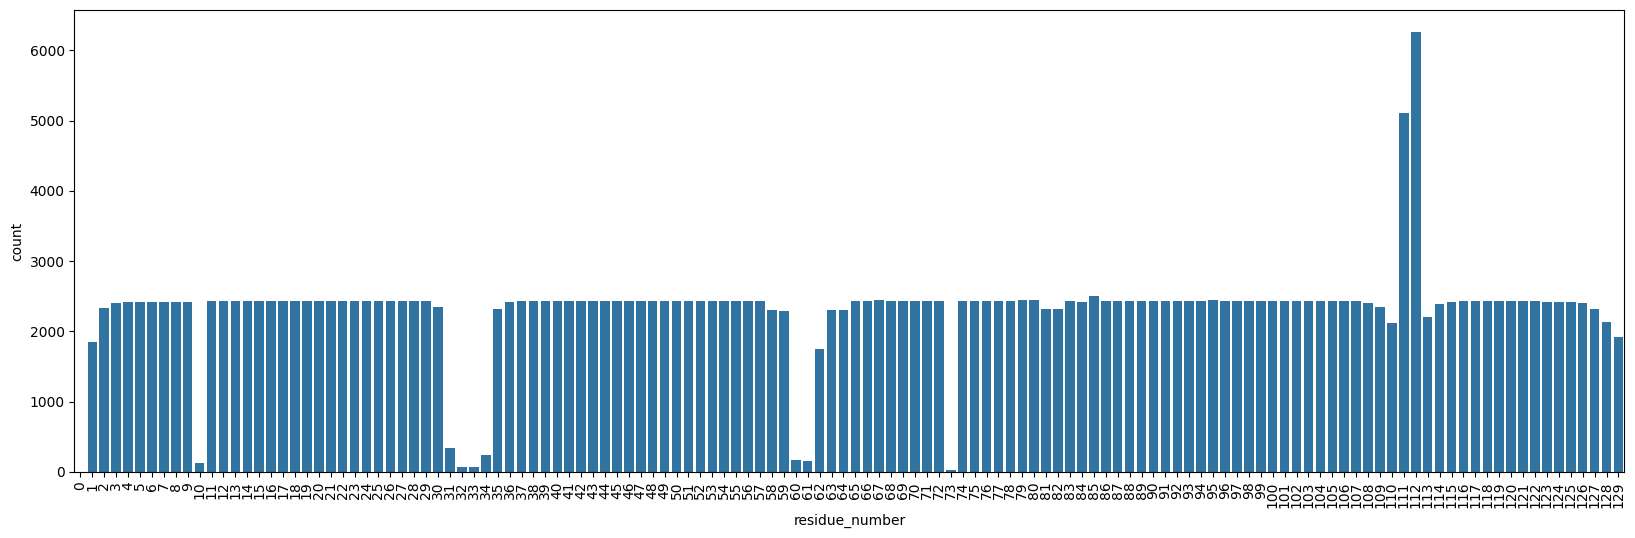

In [147]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.countplot(df[(df.chain_id == 'H') & (df.residue_number <= 129)], x='residue_number',ax=ax)
# rotate x labels for better readability
plt.xticks(rotation=90)


In [148]:
df[(df.residue_number == 34)]

,pdb_id,organism,abid,v_gene,j_gene,heavy_chain_id,light_chain_id,chain_id,residue_number,insertion_code,amino_acid,sasa_with_antigen,sasa_without_antigen,sasa_difference,sasa_relative_change,rsa_with_antigen,rsa_without_antigen,rsa_difference,rsa_relative_change,ca_coordinates,is_cdr
125,8hpf,human_ig,8hpfMN,"IGHV3,IGHV2",unknown,M,N,H,34,NaN,T,0.441860,0.441860,0.000000,0.000000,0.002569,0.002569,0.000000,0.000000,"(np.float32(189.669), np.float32(159.61), np.f...",True
1434,7d0d,human_ig,7d0dGF,IGHV2,unknown,G,F,H,34,NaN,T,0.569767,0.569767,0.000000,0.000000,0.003313,0.003313,0.000000,0.000000,"(np.float32(180.362), np.float32(236.923), np....",True
3937,3l5y,human_ig,3l5yHL,IGHV2,unknown,H,L,H,34,NaN,T,0.395349,0.395349,0.000000,0.000000,0.002299,0.002299,0.000000,0.000000,"(np.float32(0.978), np.float32(33.33), np.floa...",True
18472,7bq5,human_ig,7bq5HL,IGHV4,unknown,H,L,H,34,NaN,T,0.203488,0.203488,0.000000,0.000000,0.001183,0.001183,0.000000,0.000000,"(np.float32(-75.513), np.float32(12.281), np.f...",True
19779,8e6k,human_ig,8e6kGK,IGHV4,unknown,G,K,H,34,NaN,S,0.167742,0.180645,-0.012903,-0.071429,0.001082,0.001165,-0.000083,-0.071429,"(np.float32(98.712), np.float32(138.859), np.f...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1722858,8err,human_ig,8errHL,IGHV2,unknown,H,L,H,34,NaN,T,0.296512,0.296512,0.000000,0.000000,0.001724,0.001724,0.000000,0.000000,"(np.float32(264.371), np.float32(232.576), np....",True
1725594,3tje,human_ig,3tjeHL,IGHV4,IGHJ3,H,L,H,34,NaN,A,0.550388,0.550388,0.000000,0.000000,0.004267,0.004267,0.000000,0.000000,"(np.float32(-16.811), np.float32(34.509), np.f...",True
1732516,8tm1,human_ig,8tm1HL,IGHV4,unknown,H,L,H,34,NaN,T,0.098837,0.284884,-0.186047,-0.653061,0.000575,0.001656,-0.001082,-0.653061,"(np.float32(233.789), np.float32(224.625), np....",True
1736934,7t8w,human_ig,7t8wHL,IGHV4,unknown,H,L,H,34,NaN,S,0.748387,0.748387,0.000000,0.000000,0.004828,0.004828,0.000000,0.000000,"(np.float32(-38.729), np.float32(6.151), np.fl...",True


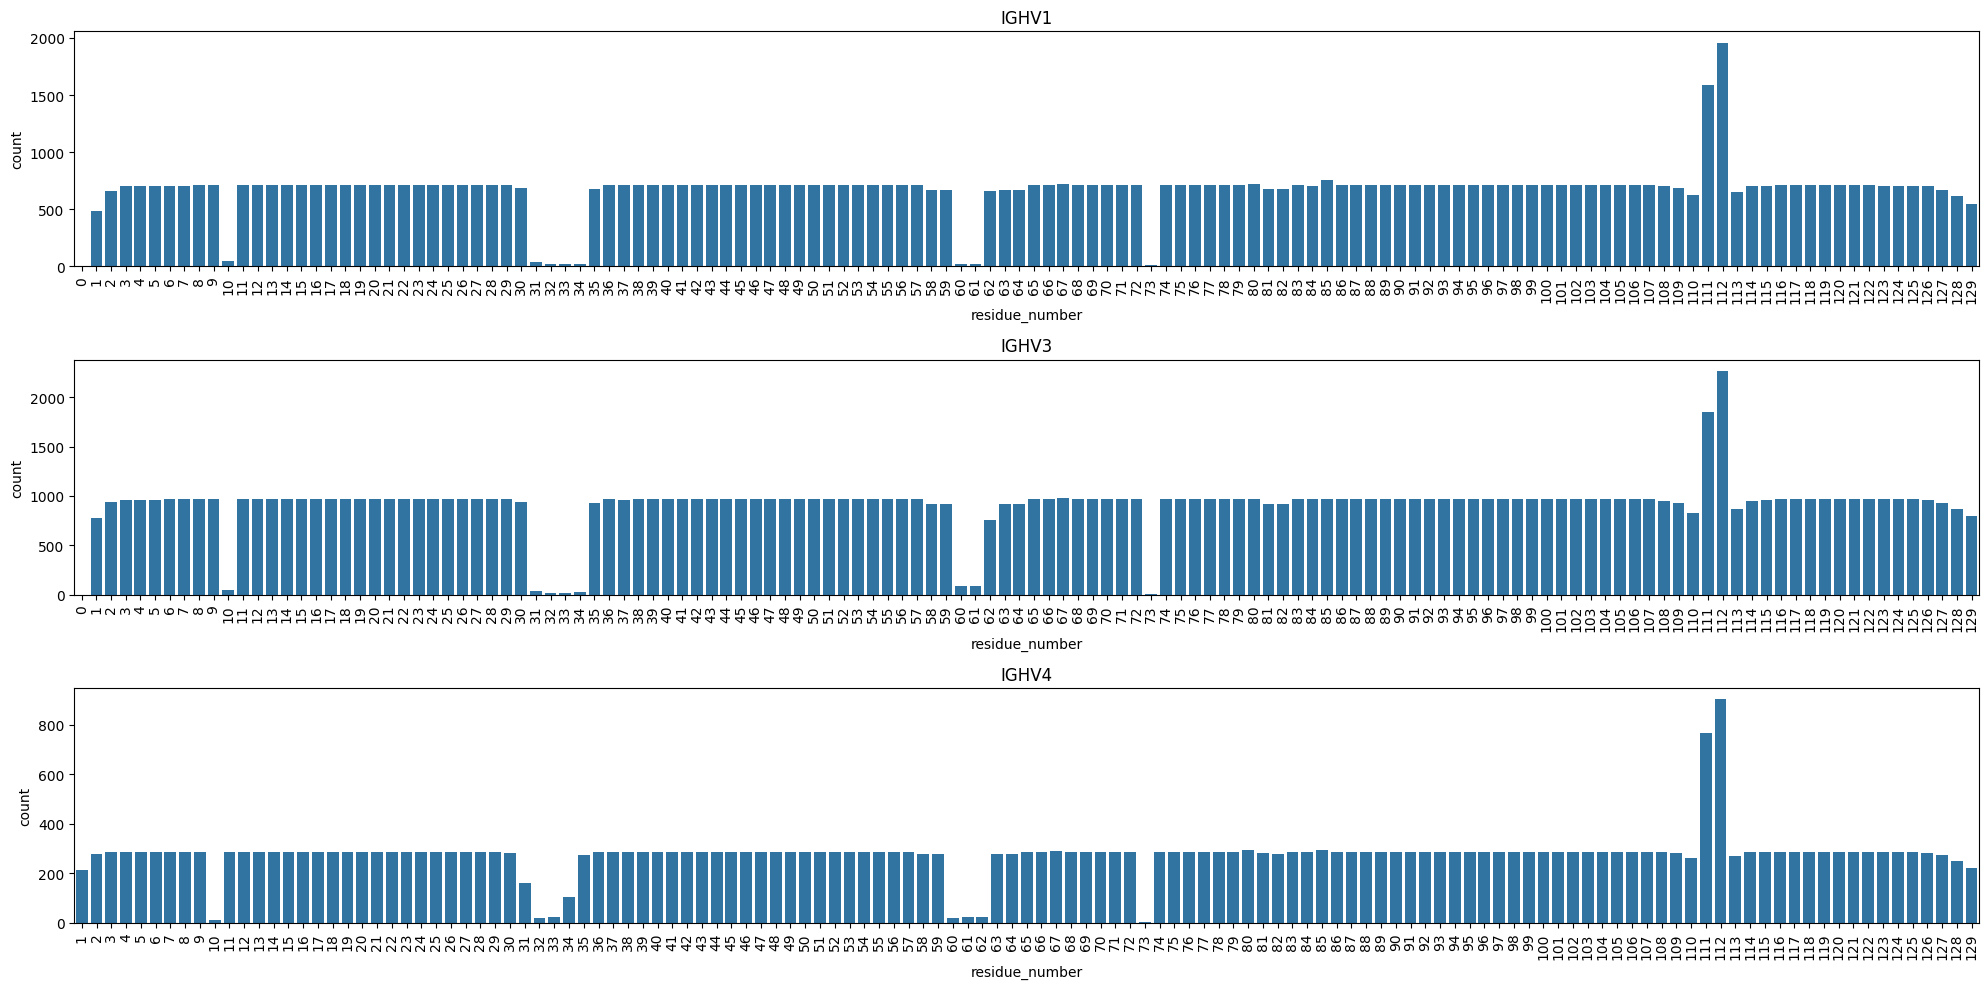

In [149]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Define the gene types you want to plot
gene_types = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(gene_types):
    # Filter data for each gene type
    filtered_data = df[(df.residue_number <= 129) & 
                      (df.v_gene == gene_type)]
    
    # Create countplot for each subplot
    sns.countplot(data=filtered_data, x='residue_number', ax=axes[i])
    
    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

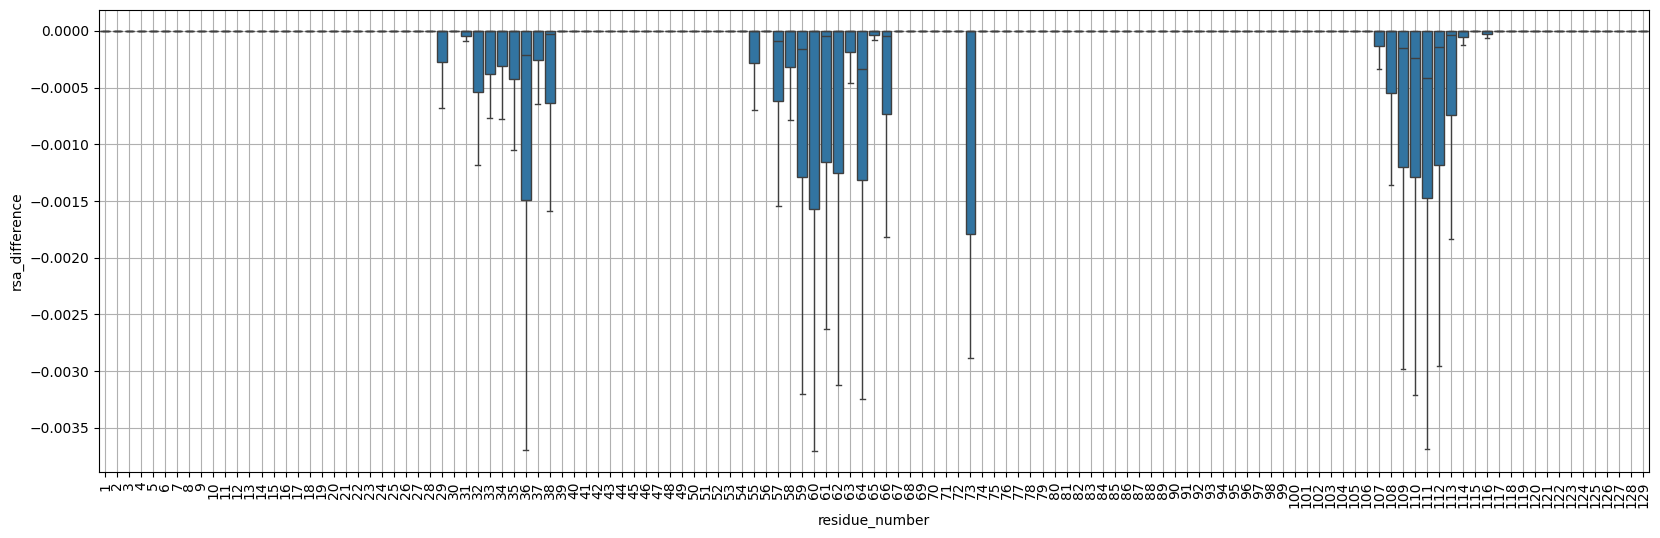

In [150]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(df[(df.chain_id == 'H')  & (df.residue_number <= 129) & (df.residue_number > 0)], x='residue_number', y='rsa_difference', ax=ax, showfliers=False)
# rotate x labels for better readability
plt.xticks(rotation=90)
ax.grid()


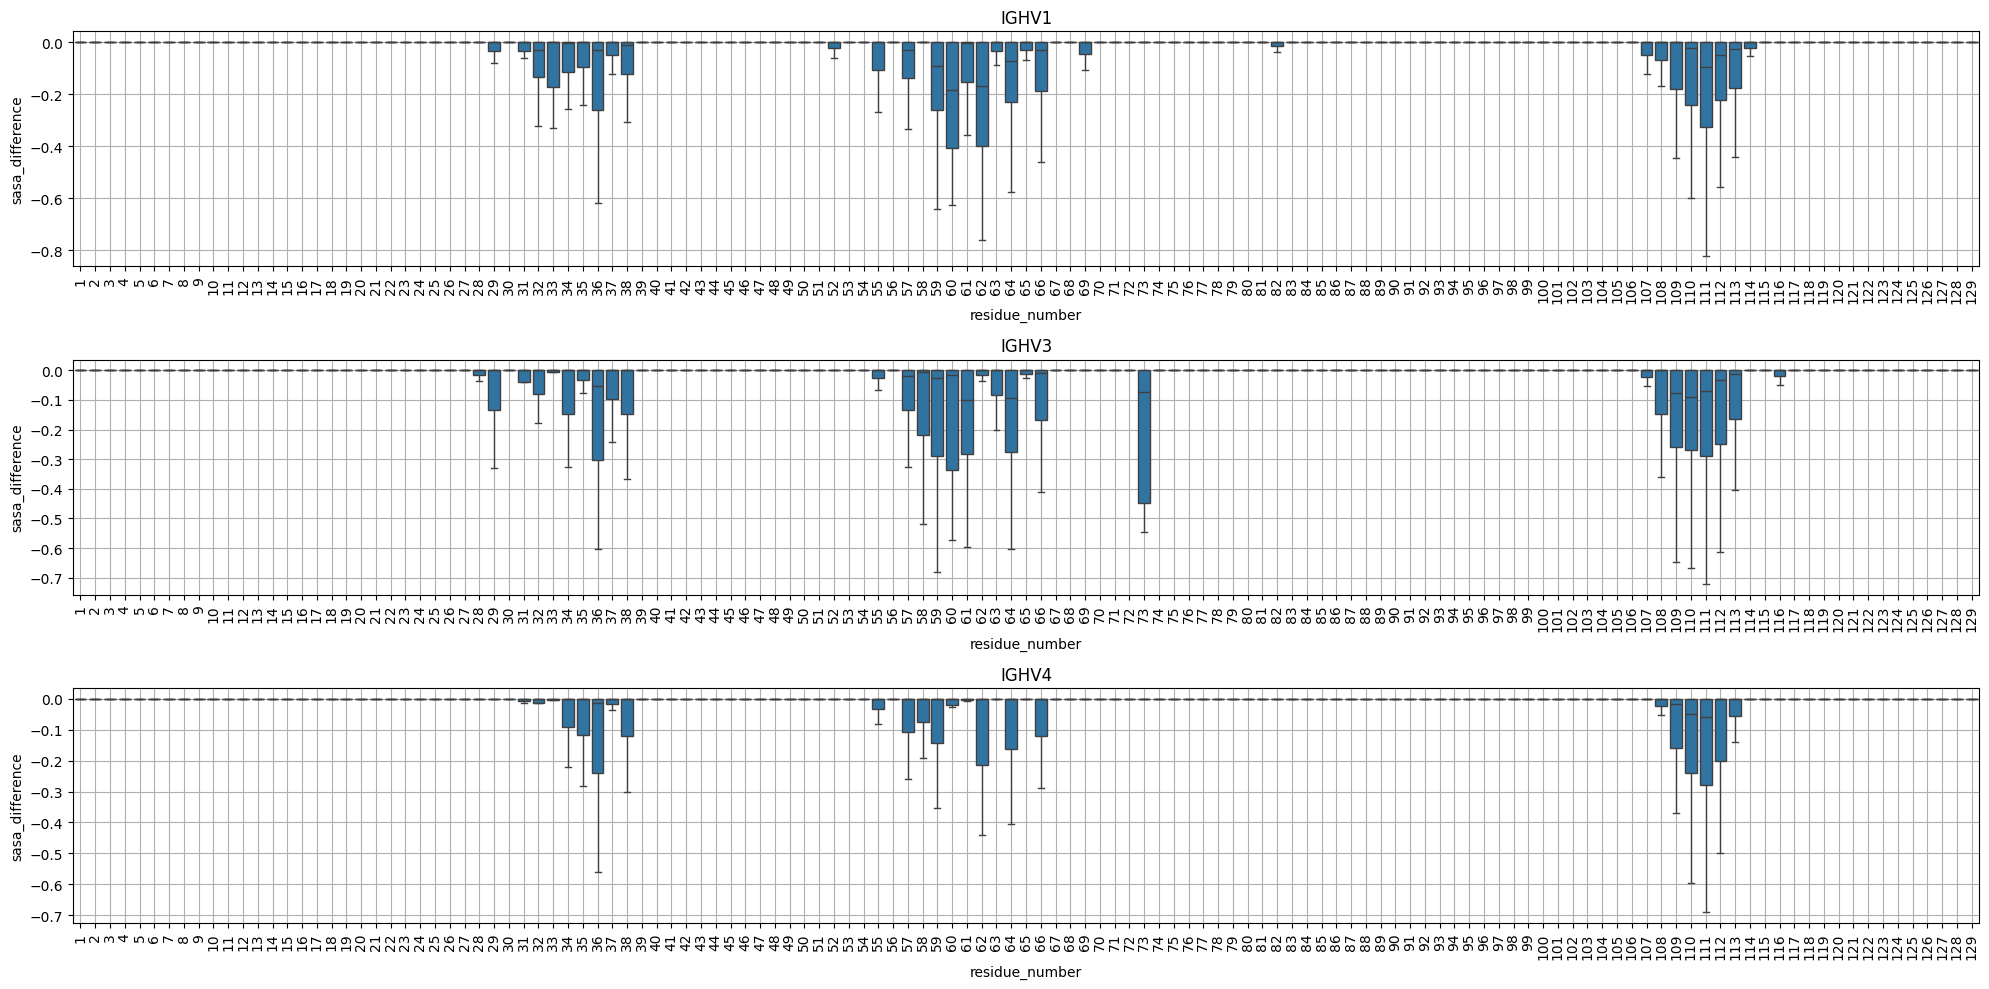

In [151]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Define the gene types you want to plot
gene_types = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(gene_types):
    # Filter data for each gene type
    filtered_data = df[(df.chain_id == 'H') & 
                      (df.residue_number <= 129) & (df.residue_number > 0) &
                      (df.v_gene == gene_type)]
    
    # Create countplot for each subplot
    sns.boxplot(data=filtered_data, x='residue_number', y='sasa_difference', showfliers=False, ax=axes[i])

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [152]:
# IGHV3 deep dive    
df_v3 = df[(df.residue_number <= 129) & 
                      (df.v_gene == 'IGHV3') ]

In [153]:
df_v3[df_v3.residue_number == 38].groupby('amino_acid').size()

amino_acid
A    185
D     34
E      9
F      4
G    170
H      5
I     11
K      1
L      3
M      3
N     13
P     11
Q      4
R      7
S    115
T     47
V     16
W    120
Y    208
dtype: int64

<Axes: xlabel='amino_acid', ylabel='count'>

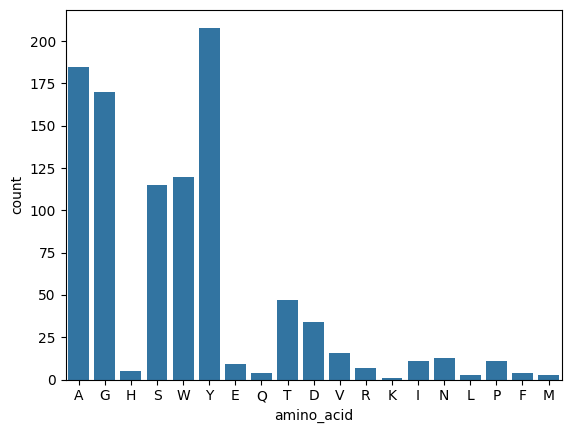

In [154]:
sns.countplot(df_v3[df_v3.residue_number == 38], x='amino_acid')

<Axes: xlabel='amino_acid', ylabel='sasa_difference'>

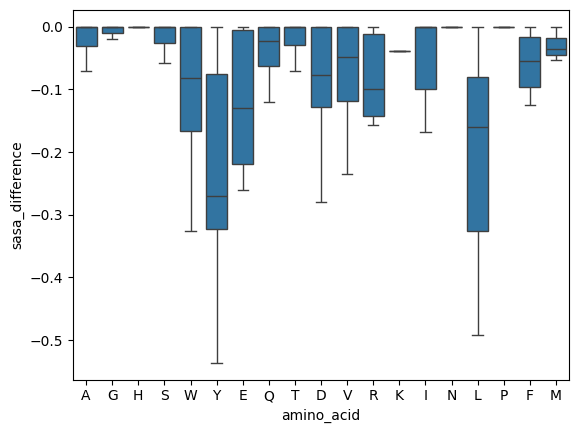

In [155]:
sns.boxplot(df_v3[df_v3.residue_number == 38], x='amino_acid', y='sasa_difference', showfliers=False)

<Axes: xlabel='amino_acid', ylabel='sasa_difference'>

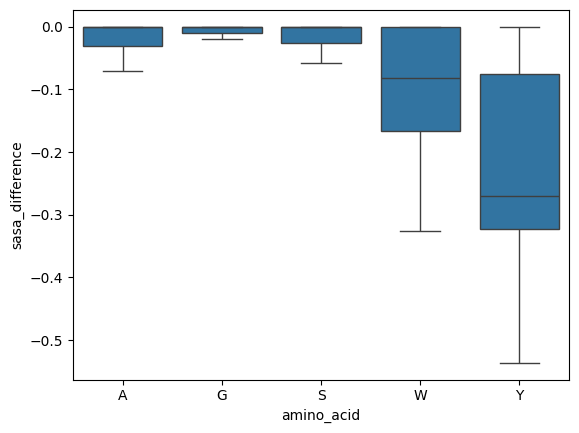

In [156]:
# only top amino acids, to hopefully only look at germline residues (although they coult have mtuated from one germline to another within V3...)

top_5_aas = df_v3[df_v3.residue_number == 38]['amino_acid'].value_counts().nlargest(5).index.tolist()
sns.boxplot(df_v3[(df_v3.residue_number == 38) & (df_v3.amino_acid.isin(top_5_aas))], x='amino_acid', y='sasa_difference', showfliers=False)



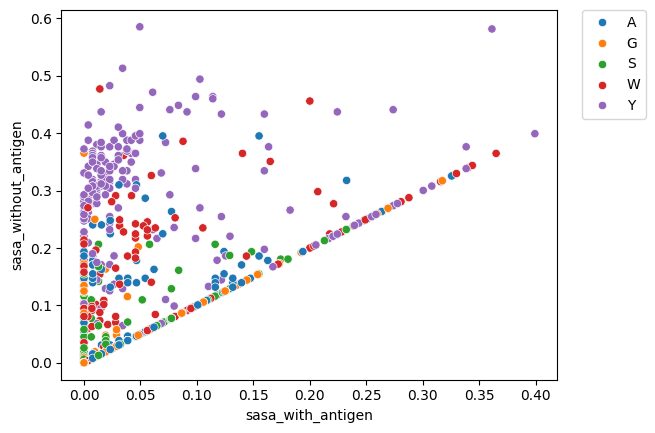

In [157]:
sns.scatterplot(df_v3[(df_v3.residue_number == 38) & (df_v3.amino_acid.isin(top_5_aas))], x='sasa_with_antigen', y='sasa_without_antigen', hue='amino_acid')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

<Axes: xlabel='amino_acid', ylabel='sasa_difference'>

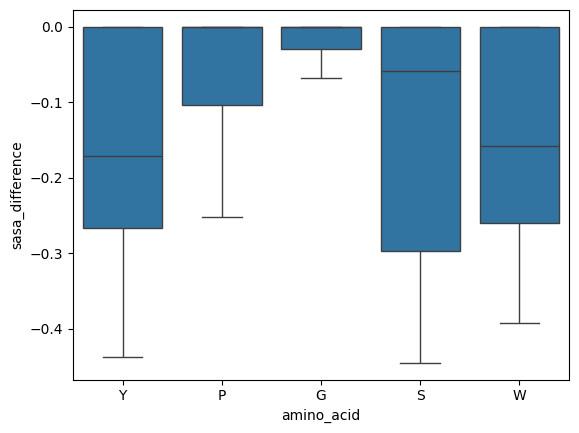

In [158]:
# only top amino acids, to hopefully only look at germline residues (although they coult have mtuated from one germline to another within V3...)

top_5_aas = df_v3[df_v3.residue_number == 58]['amino_acid'].value_counts().nlargest(5).index.tolist()
sns.boxplot(df_v3[(df_v3.residue_number == 58) & (df_v3.amino_acid.isin(top_5_aas))], x='amino_acid', y='sasa_difference', showfliers=False)



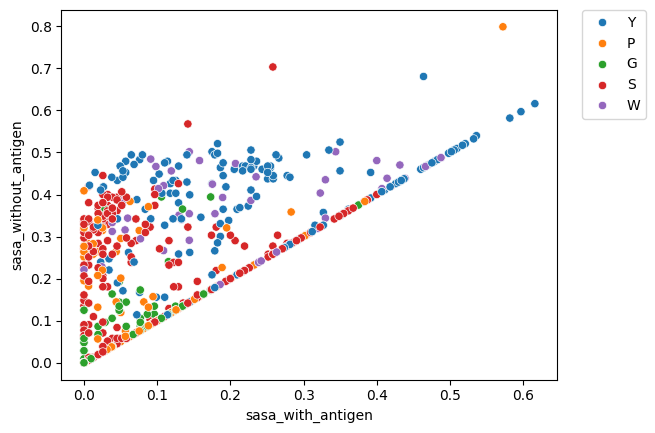

In [159]:
sns.scatterplot(df_v3[(df_v3.residue_number == 58) & (df_v3.amino_acid.isin(top_5_aas))], x='sasa_with_antigen', y='sasa_without_antigen', hue='amino_acid')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

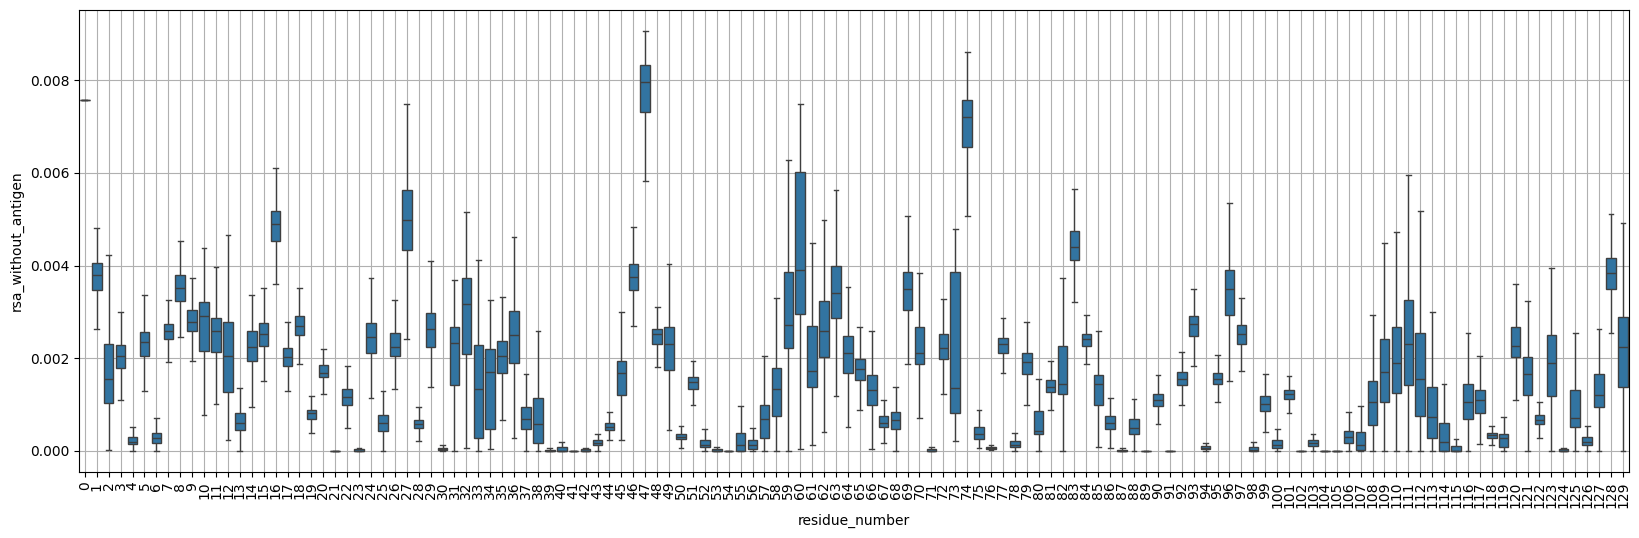

In [160]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(df_v3, x='residue_number', y='rsa_without_antigen', ax=ax, showfliers=False)
ax.tick_params(axis='x', rotation=90)
ax.grid()


<Axes: >

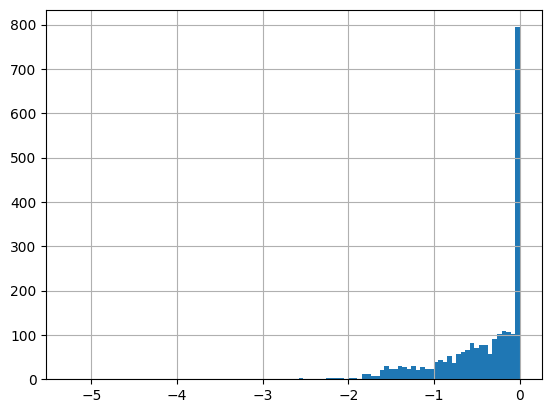

In [161]:
df[df.residue_number.isin(range(27,39))].groupby('pdb_id').sasa_difference.sum().hist(bins=100)

In [162]:
# IGHV3 deep dive    
df_v4 = df[(df.residue_number <= 129) & 
                      (df.v_gene == 'IGHV4') ]

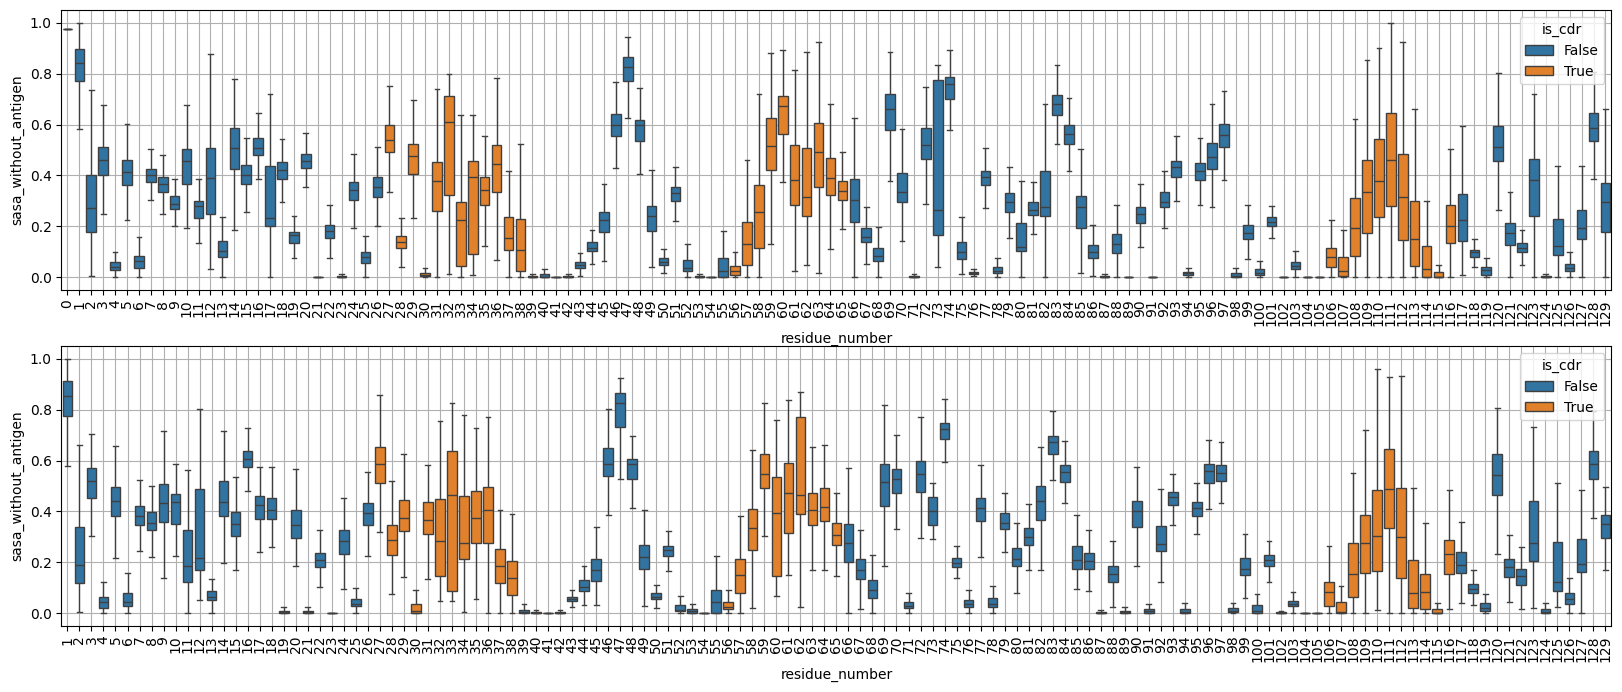

In [163]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))
sns.boxplot(df_v3, x='residue_number', y='sasa_without_antigen', ax=axes[0], showfliers=False, hue='is_cdr')
sns.boxplot(df_v4, x='residue_number', y='sasa_without_antigen', ax=axes[1], showfliers=False, hue='is_cdr')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.grid()


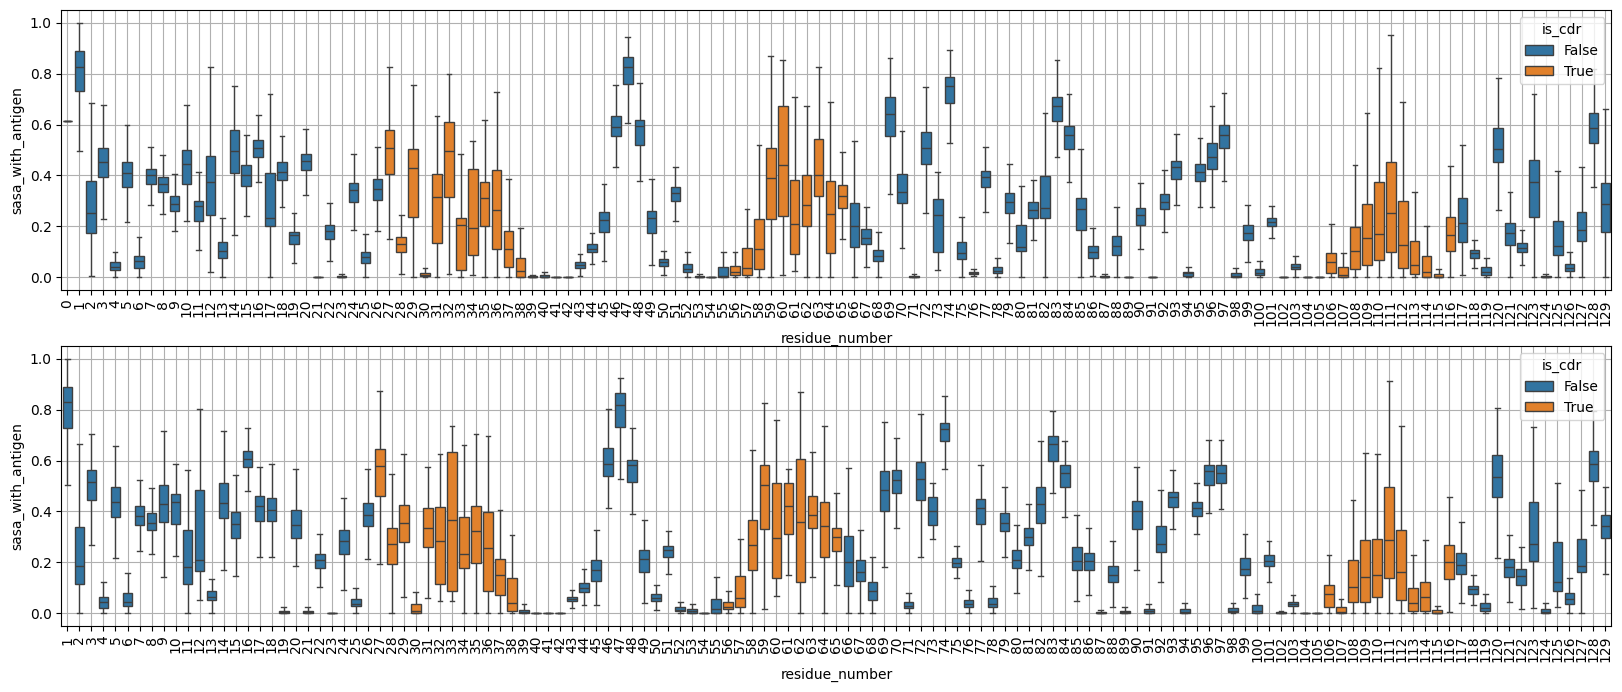

In [165]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))
sns.boxplot(df_v3, x='residue_number', y='sasa_with_antigen', ax=axes[0], showfliers=False, hue='is_cdr')
sns.boxplot(df_v4, x='residue_number', y='sasa_with_antigen', ax=axes[1], showfliers=False, hue='is_cdr')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.grid()


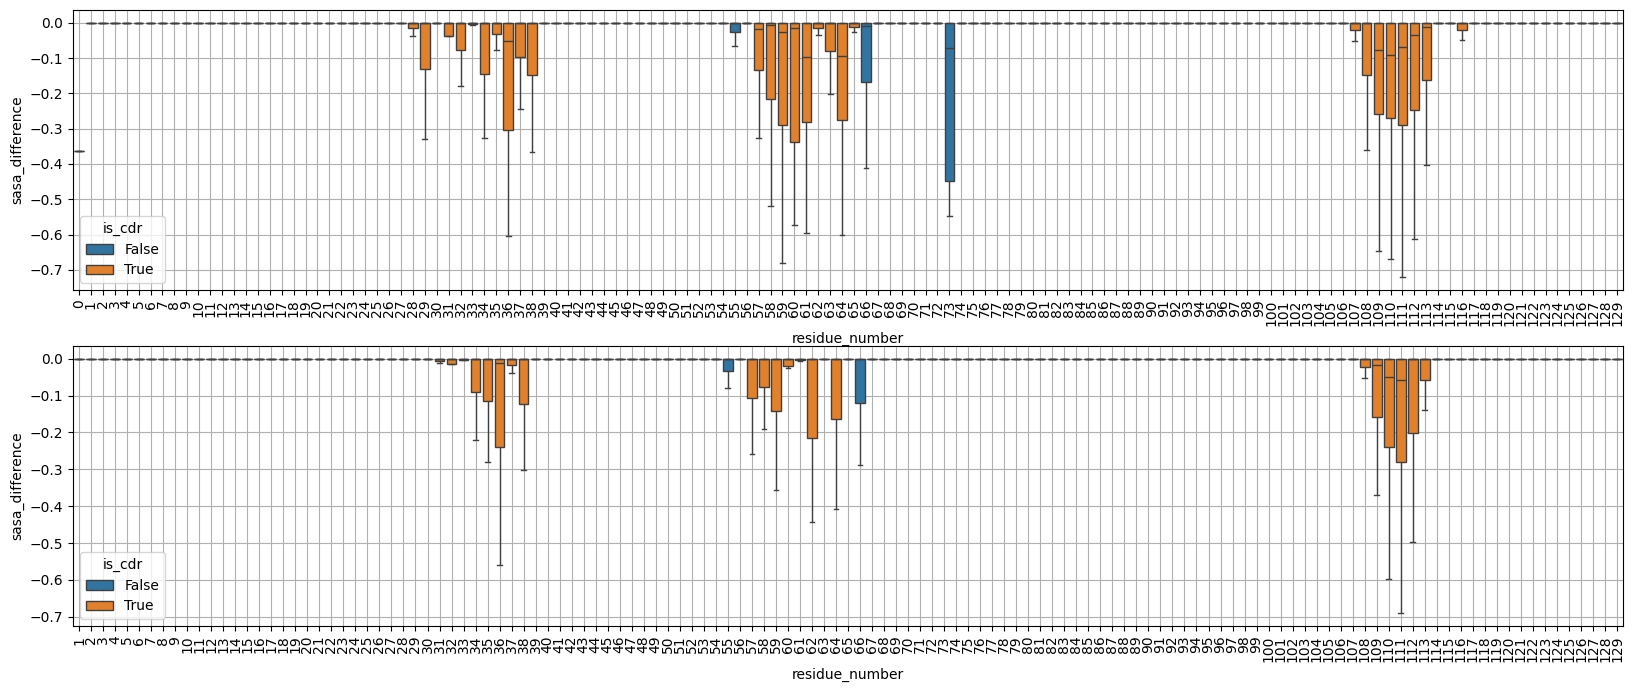

In [166]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))
sns.boxplot(df_v3, x='residue_number', y='sasa_difference', ax=axes[0], showfliers=False, hue='is_cdr')
sns.boxplot(df_v4, x='residue_number', y='sasa_difference', ax=axes[1], showfliers=False, hue='is_cdr')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.grid()


In [168]:
df.grouby('pdb_id')

AttributeError: 'DataFrame' object has no attribute 'grouby'

In [ ]:
## get the heavy chain sequences to run in anarci
metadata = pd.read_table('/fh/fast/matsen_e/shared/bcr-mut-sel/sabdab/sabdab_summary_for_dnsm.tsv')
metadata_h = metadata[['pdbid', 'chainseq_b']]

fasta_str = ''
for i in metadata_h.itertuples():
    fasta_str += f'>{i.pdbid}\n{i.chainseq_b}\n'

with open('_output/sabdab_heavy_chain_sequences.fasta', 'w') as f:
    f.write(fasta_str)


In [183]:
!cd _output && ANARCI -i sabdab_heavy_chain_sequences.fasta -o sabdab_heavy_chain_anarci.csv --scheme imgt --ncpu 10 --csv --assign_germline

Limiting hmmer search to species ['human', 'mouse'] was requested but hits did not achieve a high enough bitscore. Reverting to using any species
Limiting hmmer search to species ['human', 'mouse'] was requested but hits did not achieve a high enough bitscore. Reverting to using any species


,organism,pdbid,abid,resolution,method,pdbfile,va,ja,cdr3a,va_mismatches,ja_mismatches,core_check_a,chainseq_a,vb,jb,cdr3b,vb_mismatches,jb_mismatches,core_check_b,chainseq_b
0,mouse_ig,1a2y,1a2yBA,1.5,X-RAY DIFFRACTION,/home/pbradley/csdat/sabdab/ig_only/1a2yBA_ig_...,IGKV12-41*01,IGKJ1*01,CQHFWSTPRTF,5,0,True,DIVLTQSPASLSASVGETVTITCRASGNIHNYLAWYQQKQGKSPQL...,IGHV2-6-7*01,IGHJ4*01,CARERDYRLDYW,3,2,True,QVQLQESGPGLVAPSQSLSITCTVSGFSLTGYGVNWVRQPPGKGLE...
1,mouse_ig,1a3r,1a3rHL,2.1,X-RAY DIFFRACTION,/home/pbradley/csdat/sabdab/ig_only/1a3rHL_ig_...,IGKV8-19*01,IGKJ5*01,CQNNYNYPLTF,7,0,True,DIVMTQSPSSLTVTTGEKVTMTCKSSQSLLNSRTQKNYLTWYQQKP...,IGHV14-3*02,IGHJ4*01,CDGYYSYYDMDYW,8,1,True,VQLQQSGAELVRPGASVKLSCTTSGFNIKDIYIHWVKQRPEQGLEW...
2,mouse_ig,1acy,1acyHL,3.0,X-RAY DIFFRACTION,/home/pbradley/csdat/sabdab/ig_only/1acyHL_ig_...,IGKV3-10*01,IGKJ5*01,CQQNNEDPPTF,6,1,True,DIVMTQSPASLVVSLGQRATISCRASESVDSYGKSFMHWYQQKPGQ...,IGHV12-1-1*01,IGHJ1*01,CSRENHMYETYFDVW,8,1,True,QVKLQESGPAVIKPSQSLSLTCIVSGFSITRTNYCWHWIRQAPGKG...
3,human_ig,1adq,1adqHL,3.15,X-RAY DIFFRACTION,/home/pbradley/csdat/sabdab/ig_only/1adqHL_ig_...,IGLV3-21*02,IGLJ3*01,CQVWDSSSDHAVF,1,0,True,YVLTQPPSVSVAPGQTARITCGGNNIGSKSVHWYQQKPGQAPVLVV...,IGHV3-9*01,IGHJ4*01,CAKTRSYVVAAEYYFHYW,8,1,True,EVQLVESGGGLVQPGRSLRLSCVTSGFTFDDYAMHWVRQSPGKGLE...
4,mouse_ig,1afv,1afvKM,3.7,X-RAY DIFFRACTION,/home/pbradley/csdat/sabdab/ig_only/1afvKM_ig_...,IGKV3-2*01,IGKJ5*01,CQQSKEVPLTF,2,1,True,DIVLTQSPASLAVSLGQRATISCRASESVDNYGISFMNWFQQKPGQ...,IGHV1S130*01,IGHJ2*01,CARWRYGSPYYFDYW,2,0,True,QVQLQQPGSVLVRPGASVKLSCKASGYTFTSSWIHWAKQRPGQGLE...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7042,human_ig,7lxm,7lxmPO,3.41,ELECTRON MICROSCOPY,/home/pbradley/csdat/sabdab/ig_only/7lxmPO_ig_...,IGLV3-21*02,IGLJ5*01,CHIWDSRRPTNWVF,21,2,True,PTFVSVAPGQTARITCGEESLGSRSVIWYQQRPGQAPSLIIYNNND...,IGHV4-4*08,IGHJ6*04,CATTKHGRRIYGVVAFKEWFTYFYMDVW,26,1,True,QVHLQESGPGLVKPSETLSLTCNVSGTLVRDNYWSWIRQPLGKQPE...
7043,human_ig,7lxn,7lxnJN,3.85,ELECTRON MICROSCOPY,/home/pbradley/csdat/sabdab/ig_only/7lxnJN_ig_...,IGLV3-21*02,IGLJ5*01,CHIWDSRRPTNWVF,21,2,True,PTFVSVAPGQTARITCGEESLGSRSVIWYQQRPGQAPSLIIYNNND...,IGHV4-4*08,IGHJ6*04,CATTKHGRRIYGVVAFKEWFTYFYMDVW,26,1,True,QVHLQESGPGLVKPSETLSLTCNVSGTLVRDNYWSWIRQPLGKQPE...
7044,human_ig,7lxn,7lxnIM,3.85,ELECTRON MICROSCOPY,/home/pbradley/csdat/sabdab/ig_only/7lxnIM_ig_...,IGLV3-21*02,IGLJ5*01,CHIWDSRRPTNWVF,21,2,True,PTFVSVAPGQTARITCGEESLGSRSVIWYQQRPGQAPSLIIYNNND...,IGHV4-4*08,IGHJ6*04,CATTKHGRRIYGVVAFKEWFTYFYMDVW,26,1,True,QVHLQESGPGLVKPSETLSLTCNVSGTLVRDNYWSWIRQPLGKQPE...
7045,human_ig,7lxn,7lxnHL,3.85,ELECTRON MICROSCOPY,/home/pbradley/csdat/sabdab/ig_only/7lxnHL_ig_...,IGLV3-21*02,IGLJ5*01,CHIWDSRRPTNWVF,21,2,True,PTFVSVAPGQTARITCGEESLGSRSVIWYQQRPGQAPSLIIYNNND...,IGHV4-4*08,IGHJ6*04,CATTKHGRRIYGVVAFKEWFTYFYMDVW,26,1,True,QVHLQESGPGLVKPSETLSLTCNVSGTLVRDNYWSWIRQPLGKQPE...
